# GOES-18 ABI SO₂ / Volcanic Emissions RGB — Full Disk, CONUS, Mesoscale, and domain

## Goal

Use real GOES-18 ABI files from the 3 October 2023 19:00 UTC window. Render
the composite as Full Disk first, then CONUS, Mesoscale 1, and a decimal
user-defined Shishaldin domain.

Every displayed result is generated by the notebook and contains
longitude/latitude grid lines, labels, and coastlines.

## Setup

Install the notebook environment once:

```bash
python -m pip install -r requirements-notebooks.txt
```

The Full Disk Shishaldin scene is approximately two hours after the Alaska
Volcano Observatory reported that the significant explosive phase ended. The
RGB is qualitative and should not be presented as a direct ash or SO₂
concentration measurement.

Source: [USGS/AVO Daily Update](https://volcanoes.usgs.gov/hans-public/notice/DOI-USGS-AVO-2023-10-03T11%3A47%3A46-08%3A00).

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
from PIL import Image as PillowImage
from satpy import Scene

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.render_satellite import (
    crop_and_resample_scene,
    resample_to_max_size,
    save_dataset_with_lonlat_grid,
    validate_bbox,
)

## Parameters

In [2]:
DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
COVERAGES = ("full_disk", "conus", "mesoscale")
CHANNELS = ('C09', 'C10', 'C11', 'C13')
DOMAIN = (-170.0, 53.0, -160.0, 58.0)
DOMAIN_RESOLUTION = 0.02
COMPOSITE = "volcanic_emissions"
PRODUCT_LABEL = "SO₂ RGB"
OUTPUTS = {
    "full_disk": REPO_ROOT / "output" / "goes18_so2_rgb_20231003_1900_full_disk.png",
    "conus": REPO_ROOT / "output" / "goes18_so2_rgb_20231003_1900_conus.png",
    "mesoscale": REPO_ROOT / "output" / "goes18_so2_rgb_20231003_1900_mesoscale1.png",
    "domain": REPO_ROOT / "output" / "goes18_so2_rgb_20231003_1900_shishaldin_domain.png",
}

validate_bbox(DOMAIN)

(-170.0, 53.0, -160.0, 58.0)

## SO₂ / Volcanic Emissions RGB recipe

| Display channel | ABI calculation | Physical range | Gamma |
|---|---|---:|---:|
| Red | C09 (6.95 µm) − C10 (7.34 µm) | −4.0 to 2.0 °C | 1.0 |
| Green | C13 (10.35 µm) − C11 (8.50 µm) | −4.0 to 5.0 °C | 1.0 |
| Blue | C13 (10.35 µm) | 243.05 to 302.95 K | 1.0 |

Satpy uses `volcanic_emissions`; the former `so2`
name is deprecated. This is a qualitative RGB, not a quantitative gas
retrieval. Thick upper-level cloud can mask the signal, and low cloud can
resemble low-level SO₂.

Recipe source: [CIRA SO₂ RGB Quick Guide](https://rammb.cira.colostate.edu/training/rmtc/docs/QuickGuides/Quick_Guide_SO2_RGB.pdf).

## Source coverages shown separately

The notebook uses real NOAA products instead of treating coverage names as
interchangeable crops:

1. **Full Disk (`RadF`)** — scan start 19:00 UTC;
2. **CONUS (`RadC`)** — nearest scan start 19:01 UTC;
3. **Mesoscale 1 (`RadM1`)** — scan start 19:00 UTC;
4. **user-defined domain** — resampled from the Full Disk source.

CONUS does not cover Alaska, and the operational Mesoscale 1 sector may not
cover Shishaldin. Their images intentionally show the actual source coverage
available at that time. The Shishaldin domain must therefore be produced from
Full Disk data.

### Download each source product

In [3]:
coverage_files = {
    coverage: download_coverage(DATA_DIR, coverage, CHANNELS)
    for coverage in COVERAGES
}

for coverage, files in coverage_files.items():
    print(f"{coverage}: {len(files)} files — {SCAN_LABELS[coverage]}")
    for filename in files:
        print(f"  {Path(filename).name}")

full_disk: 4 files — 2023-10-03 19:00 UTC
  OR_ABI-L1b-RadF-M6C09_G18_s20232761900206_e20232761909520_c20232761909561.nc
  OR_ABI-L1b-RadF-M6C10_G18_s20232761900206_e20232761909526_c20232761909548.nc
  OR_ABI-L1b-RadF-M6C11_G18_s20232761900206_e20232761909514_c20232761909558.nc
  OR_ABI-L1b-RadF-M6C13_G18_s20232761900206_e20232761909526_c20232761909572.nc
conus: 4 files — 2023-10-03 19:01 UTC
  OR_ABI-L1b-RadC-M6C09_G18_s20232761901171_e20232761903550_c20232761904001.nc
  OR_ABI-L1b-RadC-M6C10_G18_s20232761901171_e20232761903556_c20232761903593.nc
  OR_ABI-L1b-RadC-M6C11_G18_s20232761901171_e20232761903545_c20232761903596.nc
  OR_ABI-L1b-RadC-M6C13_G18_s20232761901171_e20232761903556_c20232761904010.nc
mesoscale: 4 files — 2023-10-03 19:00 UTC
  OR_ABI-L1b-RadM1-M6C09_G18_s20232761900279_e20232761900343_c20232761900379.nc
  OR_ABI-L1b-RadM1-M6C10_G18_s20232761900279_e20232761900350_c20232761900374.nc
  OR_ABI-L1b-RadM1-M6C11_G18_s20232761900279_e20232761900337_c20232761900377.nc
  OR_A

### Load the composite for each coverage

In [4]:
scenes = {}
selected_composites = {}

for coverage, files in coverage_files.items():
    scene = Scene(reader="abi_l1b", filenames=files)
    available = {str(name) for name in scene.available_composite_names()}
    selected = COMPOSITE

    if selected not in available:
        raise ValueError(
            f"{COMPOSITE!r} cannot be created for {coverage}. "
            f"Available composites: {sorted(available)}"
        )
    calibration = (
        "reflectance"
        if selected in {"true_color", "true_color_raw"}
        else "brightness_temperature"
    )
    scene.load(list(CHANNELS), calibration=calibration)
    scenes[coverage] = scene
    selected_composites[coverage] = selected
    print(
        f"{coverage}: loaded source channels for {selected} "
        f"({calibration})"
    )

full_disk: loaded source channels for volcanic_emissions (brightness_temperature)
conus: loaded source channels for volcanic_emissions (brightness_temperature)
mesoscale: loaded source channels for volcanic_emissions (brightness_temperature)


## 1. Full Disk

/Users/rmsm1/Documents/Codex/2026-07-23/github-plugin-github-openai-curated-remote-5/GOES-VIIRS-Imagery-Guide/.venv/lib/python3.12/site-packages/satpy/resample/native.py:129: RuntimeWarning: Mean of empty slice
  data_mean = np.nanmean(data.reshape(new_shape), axis=(1, 3))


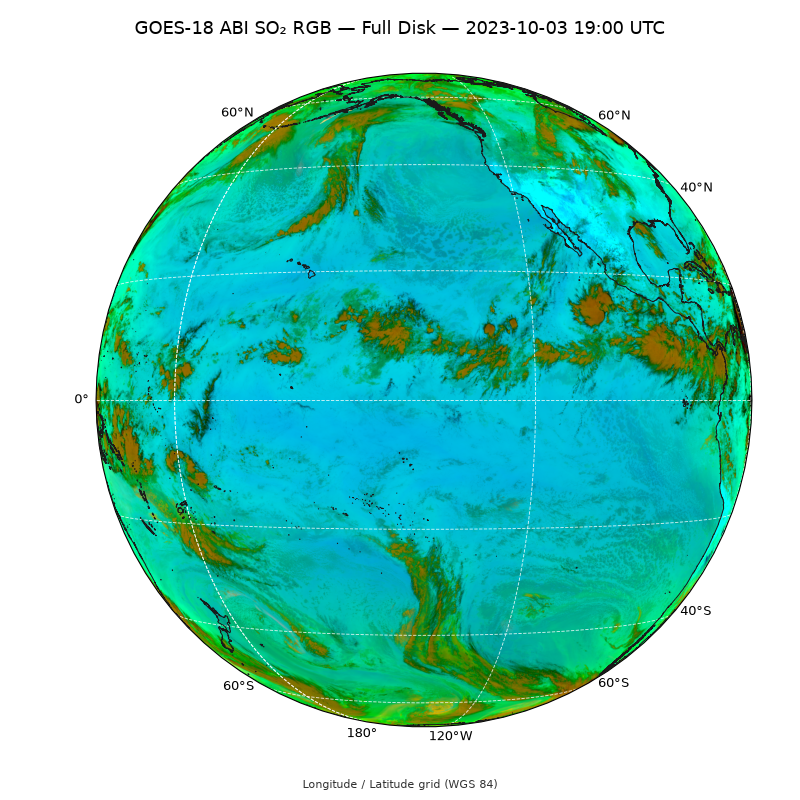

In [5]:
fulldisk_scene = resample_to_max_size(
    scenes["full_disk"],
    selected_composites["full_disk"],
    max_size=1400,
)
save_dataset_with_lonlat_grid(
    fulldisk_scene,
    selected_composites["full_disk"],
    OUTPUTS["full_disk"],
    title=f"GOES-18 ABI {PRODUCT_LABEL} — Full Disk — {SCAN_LABELS['full_disk']}",
    dpi=100,
)
display(Image(filename=str(OUTPUTS["full_disk"])))

## 2. CONUS

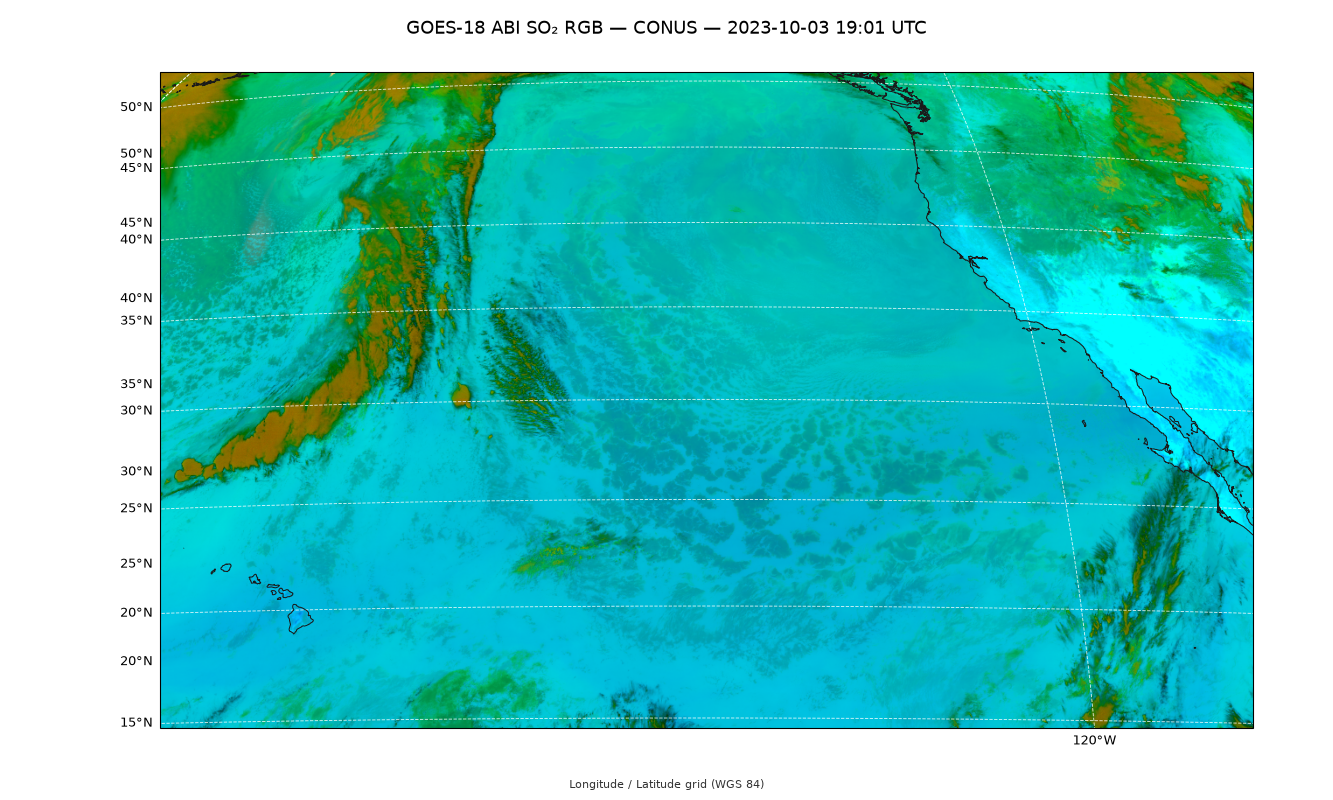

In [6]:
conus_scene = resample_to_max_size(
    scenes["conus"],
    selected_composites["conus"],
    max_size=1400,
)
save_dataset_with_lonlat_grid(
    conus_scene,
    selected_composites["conus"],
    OUTPUTS["conus"],
    title=f"GOES-18 ABI {PRODUCT_LABEL} — CONUS — {SCAN_LABELS['conus']}",
    dpi=100,
)
display(Image(filename=str(OUTPUTS["conus"])))

## 3. Mesoscale 1

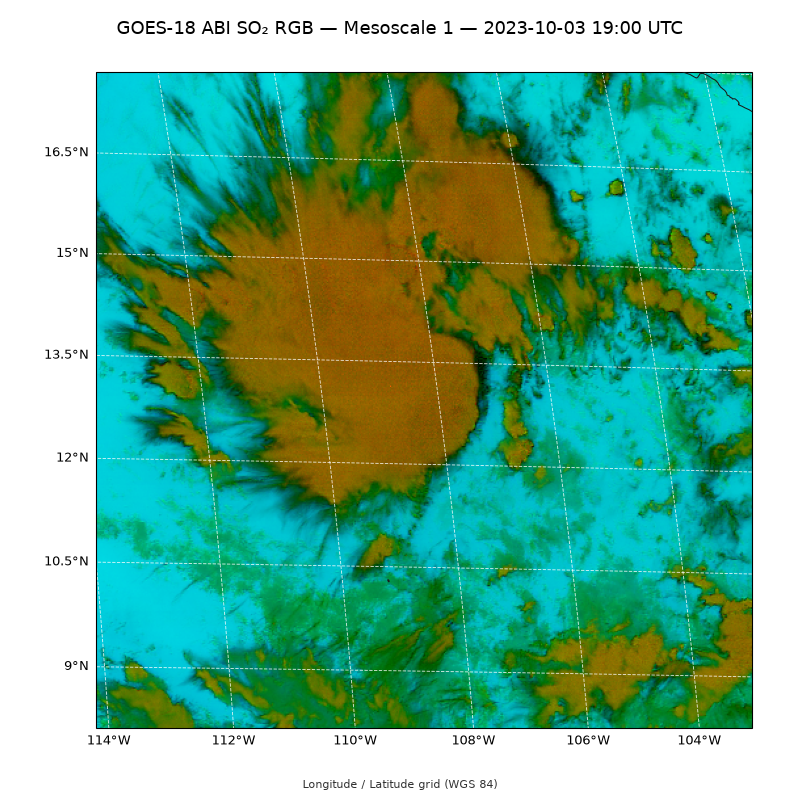

In [7]:
mesoscale_scene = resample_to_max_size(
    scenes["mesoscale"],
    selected_composites["mesoscale"],
    max_size=1400,
)
save_dataset_with_lonlat_grid(
    mesoscale_scene,
    selected_composites["mesoscale"],
    OUTPUTS["mesoscale"],
    title=f"GOES-18 ABI {PRODUCT_LABEL} — Mesoscale 1 — {SCAN_LABELS['mesoscale']}",
    dpi=100,
)
display(Image(filename=str(OUTPUTS["mesoscale"])))

## 4. User-defined Shishaldin domain

The domain is resampled from the Full Disk source because CONUS does not cover
Alaska. Change all four decimal values for another study area.

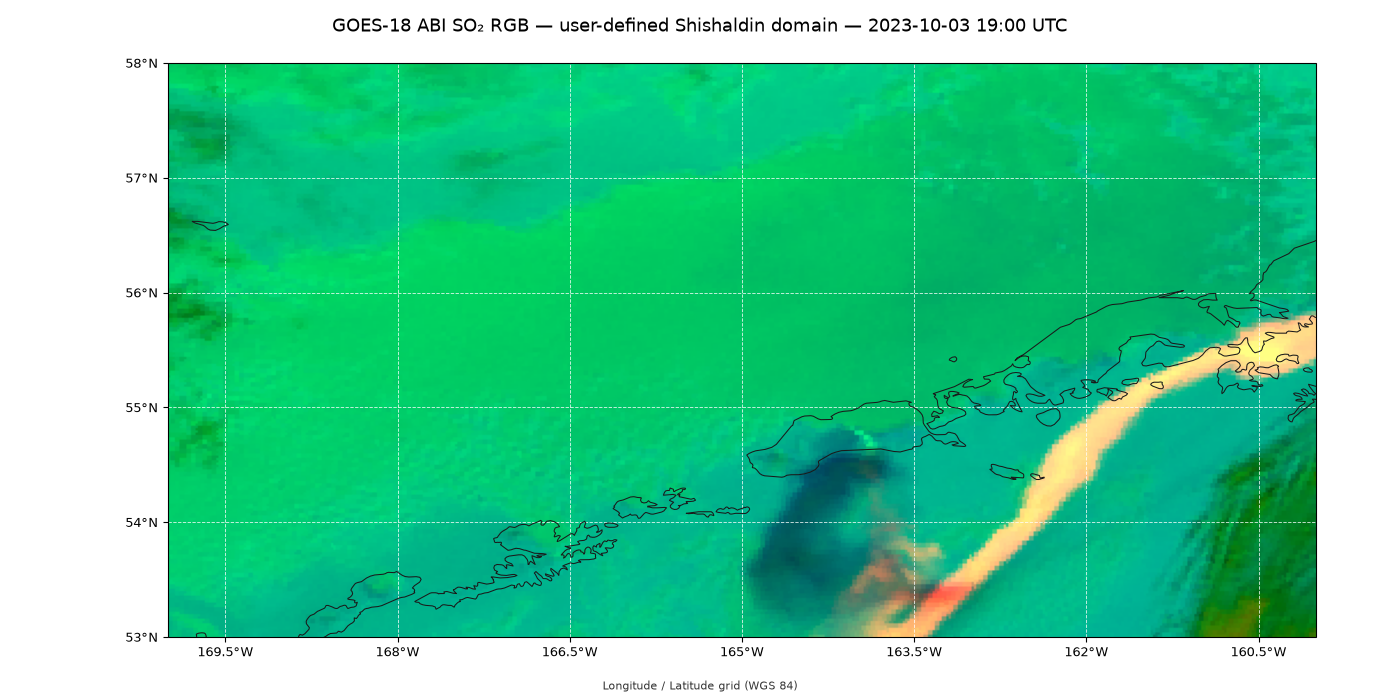

In [8]:
domain_scene = crop_and_resample_scene(
    scenes["full_disk"],
    domain=DOMAIN,
    resolution=DOMAIN_RESOLUTION,
)
try:
    domain_scene[selected_composites["full_disk"]]
except KeyError:
    domain_scene.load([selected_composites["full_disk"]], generate=True)
save_dataset_with_lonlat_grid(
    domain_scene,
    selected_composites["full_disk"],
    OUTPUTS["domain"],
    title=(
        f"GOES-18 ABI {PRODUCT_LABEL} — "
        "user-defined Shishaldin domain — 2023-10-03 19:00 UTC"
    ),
    dpi=100,
)
display(Image(filename=str(OUTPUTS["domain"])))

## Checks

In [9]:
for name, output in OUTPUTS.items():
    if not output.exists():
        raise FileNotFoundError(output)
    with PillowImage.open(output) as image:
        print(f"{name}: {image.width} x {image.height} pixels")
        assert image.width > 0 and image.height > 0

full_disk: 800 x 800 pixels
conus: 1333 x 800 pixels
mesoscale: 800 x 800 pixels
domain: 1400 x 700 pixels


## Next steps

Use channels from one scan only. Compare the RGB with individual bands,
independent observations, and official volcanic advisories before drawing a
scientific or operational conclusion.